In [13]:
import numpy as np
import matplotlib.pyplot as plt
import re
import os


Cantidad de vóxeles: 512
Dosis mínima [Gy]: 3.3528000000000002
Dosis máxima [Gy]: 10.8429
Dosis media [Gy]: 6.8745439453124995
CV [%]: 20.599883061310457


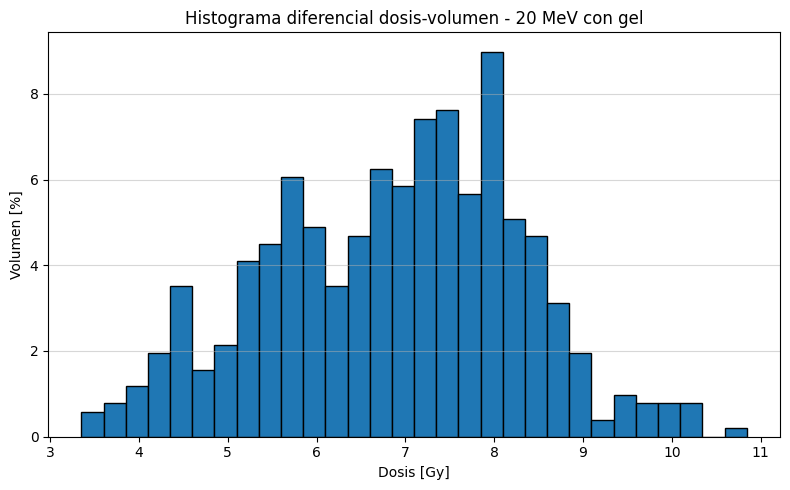

In [26]:
import re
import numpy as np
import matplotlib.pyplot as plt

def leer_dosis_xyz(archivo):
    datos = []
    ix_actual = None
    iy_actual = None
    leer_tabla = False
    contador_z = 0

    with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
        lineas = f.readlines()

    for linea in lineas:
        m = re.search(r"ix\s*=\s*(\d+).*iy\s*=\s*(\d+)", linea)

        if m:
            ix_actual = int(m.group(1)) - 1
            iy_actual = int(m.group(2)) - 1
            leer_tabla = False
            contador_z = 0
            continue

        if linea.strip().startswith("#  z-lower"):
            leer_tabla = True
            contador_z = 0
            continue

        if leer_tabla:
            partes = linea.split()

            if len(partes) < 4:
                leer_tabla = False
                continue

            try:
                valor = float(partes[2])
            except ValueError:
                leer_tabla = False
                continue

            if ix_actual is not None and iy_actual is not None:
                datos.append([ix_actual, iy_actual, contador_z, valor])
                contador_z += 1

    datos = np.array(datos)

    nx = int(np.max(datos[:, 0])) + 1
    ny = int(np.max(datos[:, 1])) + 1
    nz = int(np.max(datos[:, 2])) + 1

    dosis = np.full((nx, ny, nz), np.nan)

    for ix, iy, iz, valor in datos:
        dosis[int(ix), int(iy), int(iz)] = valor

    return dosis


def aplicar_mascara_pouch(
    dosis,
    xmin=-1.0,
    xmax=1.0,
    ymin=-1.6,
    ymax=1.6,
    zmin=60.38,
    zmax=60.58,
    x0=0.0,
    y0=0.0,
    z0=60.48,
    rx=1.0,
    ry=1.6,
    rz=1.0
):
    nx, ny, nz = dosis.shape

    x_edges = np.linspace(xmin, xmax, nx + 1)
    y_edges = np.linspace(ymin, ymax, ny + 1)
    z_edges = np.linspace(zmin, zmax, nz + 1)

    x_centros = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centros = 0.5 * (y_edges[:-1] + y_edges[1:])
    z_centros = 0.5 * (z_edges[:-1] + z_edges[1:])

    X, Y, Z = np.meshgrid(x_centros, y_centros, z_centros, indexing="ij")

    mascara = (
        ((X - x0) / rx) ** 2
        + ((Y - y0) / ry) ** 2
        + ((Z - z0) / rz) ** 2
    ) <= 1

    dosis_mascara = np.where(mascara, dosis, np.nan)

    return dosis_mascara[~np.isnan(dosis_mascara)]


archivo_20 = "histograma_dosis_arriba20gel.out"

tiempo_seg = 300
bins = 30

matriz_20 = leer_dosis_xyz(archivo_20)

dosis_20 = aplicar_mascara_pouch(
    matriz_20,
    xmin=-1.0,
    xmax=1.0,
    ymin=-1.6,
    ymax=1.6,
    zmin=60.38,
    zmax=60.58,
    x0=0.0,
    y0=0.0,
    z0=60.48,
    rx=1.0,
    ry=1.6,
    rz=1.0
)

dosis_20 = dosis_20 * tiempo_seg

peso_20 = np.ones_like(dosis_20) * 100.0 / len(dosis_20)

print("Cantidad de vóxeles:", len(dosis_20))
print("Dosis mínima [Gy]:", np.min(dosis_20))
print("Dosis máxima [Gy]:", np.max(dosis_20))
print("Dosis media [Gy]:", np.mean(dosis_20))
print("CV [%]:", 100 * np.std(dosis_20) / np.mean(dosis_20))

plt.figure(figsize=(8, 5))
plt.hist(
    dosis_20,
    bins=bins,
    weights=peso_20,
    edgecolor="black"
)
plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen - 20 MeV con gel")
plt.grid(True, axis="y", alpha=0.5)
plt.tight_layout()
plt.show()

18 MeV sin gel
Cantidad de vóxeles: 512
Dosis mínima [Gy]: 4.2762
Dosis máxima [Gy]: 7.7451
Dosis media [Gy]: 6.150933984375
CV [%]: 12.898142770629132

20 MeV con gel
Cantidad de vóxeles: 640
Dosis mínima [Gy]: 3.3528000000000002
Dosis máxima [Gy]: 10.8429
Dosis media [Gy]: 7.137459843749999
CV [%]: 20.332417996626134



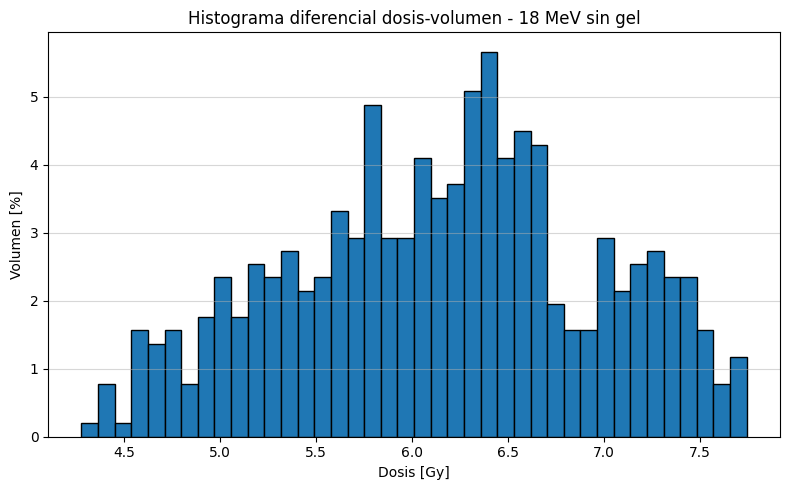

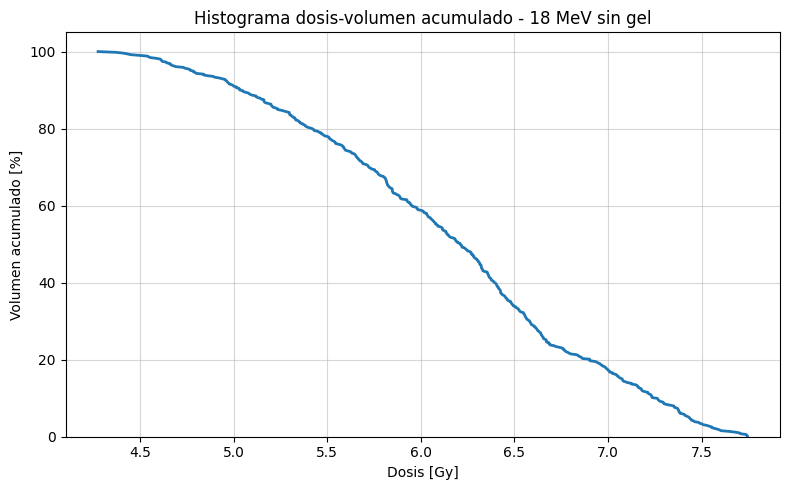

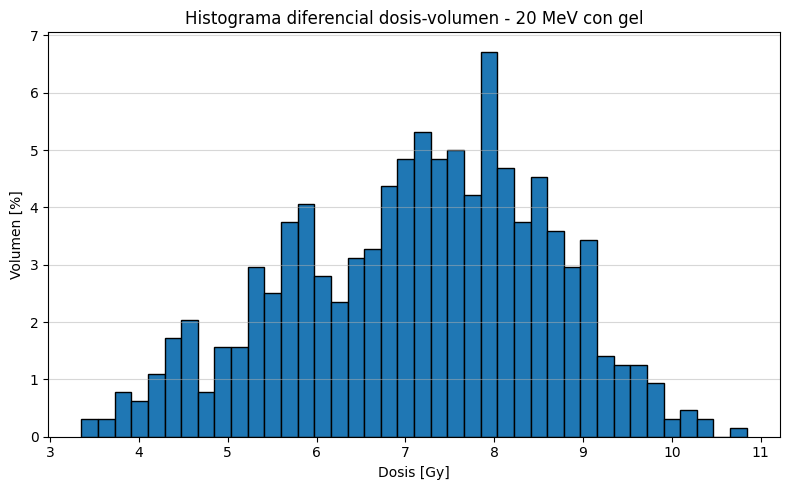

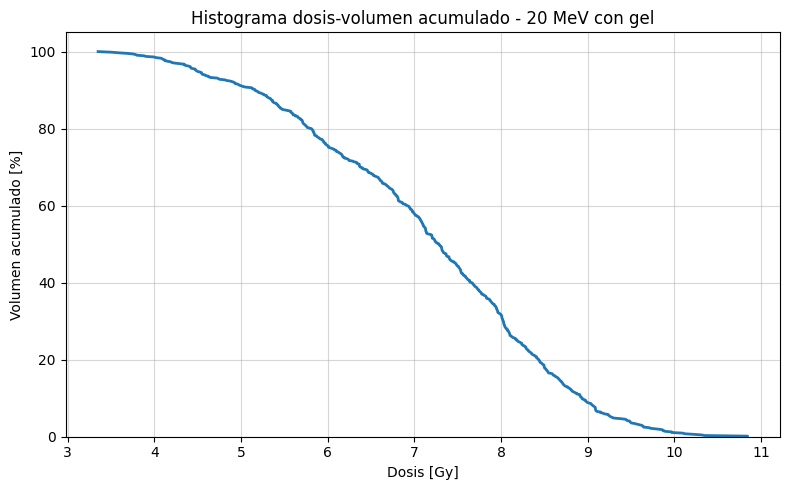

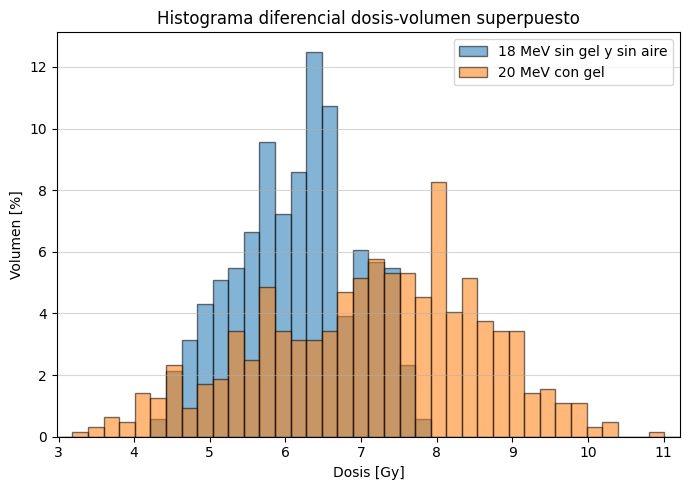

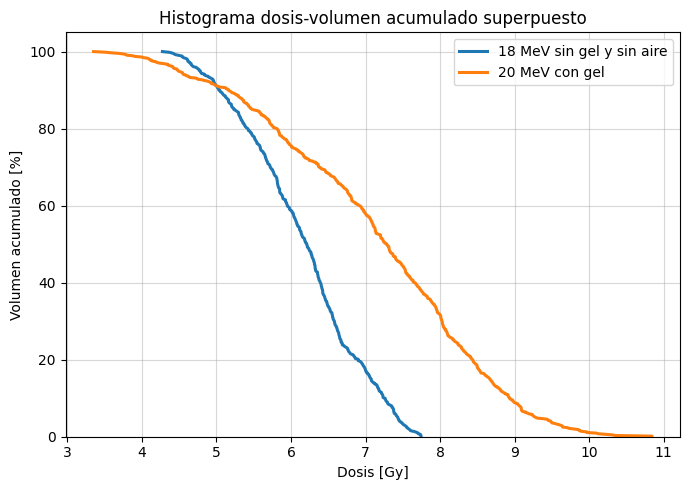

In [18]:
def leer_dosis_xyz(archivo):
    datos = []
    ix_actual = None
    iy_actual = None
    leer_tabla = False
    contador_z = 0

    with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
        lineas = f.readlines()

    for linea in lineas:
        m = re.search(r"ix\s*=\s*(\d+).*iy\s*=\s*(\d+)", linea)

        if m:
            ix_actual = int(m.group(1)) - 1
            iy_actual = int(m.group(2)) - 1
            leer_tabla = False
            contador_z = 0
            continue

        if linea.strip().startswith("#  z-lower"):
            leer_tabla = True
            contador_z = 0
            continue

        if leer_tabla:
            partes = linea.split()

            if len(partes) < 4:
                leer_tabla = False
                continue

            try:
                valor = float(partes[2])
            except ValueError:
                leer_tabla = False
                continue

            if ix_actual is not None and iy_actual is not None:
                datos.append([ix_actual, iy_actual, contador_z, valor])
                contador_z += 1

    datos = np.array(datos)

    nx = int(np.max(datos[:, 0])) + 1
    ny = int(np.max(datos[:, 1])) + 1
    nz = int(np.max(datos[:, 2])) + 1

    dosis = np.full((nx, ny, nz), np.nan)

    for ix, iy, iz, valor in datos:
        dosis[int(ix), int(iy), int(iz)] = valor

    return dosis


def aplicar_mascara_pouch(
    dosis,
    xmin=-1.0,
    xmax=1.0,
    ymin=-1.6,
    ymax=1.6,
    zmin=60.38,
    zmax=60.58,
    x0=0.0,
    y0=0.0,
    z0=60.48,
    rx=1.0,
    ry=1.6,
    rz=1.0
):
    nx, ny, nz = dosis.shape

    x_edges = np.linspace(xmin, xmax, nx + 1)
    y_edges = np.linspace(ymin, ymax, ny + 1)
    z_edges = np.linspace(zmin, zmax, nz + 1)

    x_centros = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centros = 0.5 * (y_edges[:-1] + y_edges[1:])
    z_centros = 0.5 * (z_edges[:-1] + z_edges[1:])

    X, Y, Z = np.meshgrid(x_centros, y_centros, z_centros, indexing="ij")

    mascara = (
        ((X - x0) / rx) ** 2
        + ((Y - y0) / ry) ** 2
        + ((Z - z0) / rz) ** 2
    ) <= 1

    dosis_mascara = np.where(mascara, dosis, np.nan)

    return dosis_mascara[~np.isnan(dosis_mascara)]


def dvh_acumulado(data):
    dosis_ordenada = np.sort(data)
    n = len(dosis_ordenada)

    volumen = 100.0 * (n - np.arange(n)) / n

    dosis_dvh = np.concatenate([[dosis_ordenada[0]], dosis_ordenada, [dosis_ordenada[-1]]])
    volumen_dvh = np.concatenate([[100.0], volumen, [0.0]])

    return dosis_dvh, volumen_dvh


def resumen(nombre, data):
    print(nombre)
    print("Cantidad de vóxeles:", len(data))
    print("Dosis mínima [Gy]:", np.min(data))
    print("Dosis máxima [Gy]:", np.max(data))
    print("Dosis media [Gy]:", np.mean(data))
    print("CV [%]:", 100 * np.std(data) / np.mean(data))
    print()


archivo_18 = "histograma_dosis_abajo18singel.out"
archivo_20 = "histograma_dosis_arriba20gel2.out"

tiempo_seg = 300
bins_individual = 40
bins_superpuesto = 40

for archivo in [archivo_18, archivo_20]:
    if not os.path.exists(archivo):
        raise FileNotFoundError(f"No encuentro el archivo: {archivo}")

matriz_18 = leer_dosis_xyz(archivo_18)
matriz_20 = leer_dosis_xyz(archivo_20)

dosis_18 = aplicar_mascara_pouch(
    matriz_18,
    xmin=-1.0,
    xmax=1.0,
    ymin=-1.6,
    ymax=1.6,
    zmin=60.38,
    zmax=60.58,
    x0=0.0,
    y0=0.0,
    z0=60.48,
    rx=1.0,
    ry=1.6,
    rz=1.0
)

dosis_20 = matriz_20[~np.isnan(matriz_20)]

dosis_18 = dosis_18 * tiempo_seg
dosis_20 = dosis_20 * tiempo_seg

resumen("18 MeV sin gel", dosis_18)
resumen("20 MeV con gel", dosis_20)

peso_18 = np.ones_like(dosis_18) * 100.0 / len(dosis_18)
peso_20 = np.ones_like(dosis_20) * 100.0 / len(dosis_20)

plt.figure(figsize=(8, 5))
plt.hist(dosis_18, bins=bins_individual, weights=peso_18, edgecolor="black")
plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen - 18 MeV sin gel")
plt.grid(True, axis="y", alpha=0.5)
plt.tight_layout()
plt.show()

dosis_ord_18, vol_acum_18 = dvh_acumulado(dosis_18)

plt.figure(figsize=(8, 5))
plt.plot(dosis_ord_18, vol_acum_18, linewidth=2)
plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado - 18 MeV sin gel")
plt.ylim(0, 105)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(dosis_20, bins=bins_individual, weights=peso_20, edgecolor="black")
plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen - 20 MeV con gel")
plt.grid(True, axis="y", alpha=0.5)
plt.tight_layout()
plt.show()

dosis_ord_20, vol_acum_20 = dvh_acumulado(dosis_20)

plt.figure(figsize=(8, 5))
plt.plot(dosis_ord_20, vol_acum_20, linewidth=2)
plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado - 20 MeV con gel")
plt.ylim(0, 105)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

dosis_min = min(np.min(dosis_18), np.min(dosis_20))
dosis_max = max(np.max(dosis_18), np.max(dosis_20))
margen = 0.05 * (dosis_max - dosis_min)

x_min = max(0, dosis_min - margen)
x_max = dosis_max + margen

bins_comunes = np.linspace(x_min, x_max, bins_superpuesto + 1)

plt.figure(figsize=(7, 5))
plt.hist(
    dosis_18,
    bins=bins_comunes,
    weights=peso_18,
    alpha=0.55,
    edgecolor="black",
    label="18 MeV sin gel y sin aire"
)
plt.hist(
    dosis_20,
    bins=bins_comunes,
    weights=peso_20,
    alpha=0.55,
    edgecolor="black",
    label="20 MeV con gel"
)
plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen superpuesto")
plt.xlim(x_min, x_max)
plt.grid(True, axis="y", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(dosis_ord_18, vol_acum_18, linewidth=2.2, label="18 MeV sin gel y sin aire")
plt.plot(dosis_ord_20, vol_acum_20, linewidth=2.2, label="20 MeV con gel")
plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado superpuesto")
plt.xlim(x_min, x_max)
plt.ylim(0, 105)
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

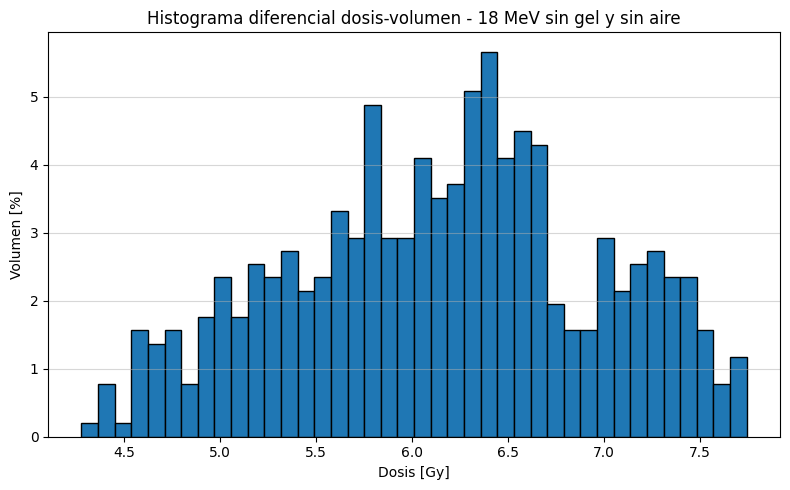

In [23]:
import re
import numpy as np
import matplotlib.pyplot as plt

def leer_dosis_xyz(archivo):
    datos = []
    ix_actual = None
    iy_actual = None
    leer_tabla = False
    contador_z = 0

    with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
        lineas = f.readlines()

    for linea in lineas:
        m = re.search(r"ix\s*=\s*(\d+).*iy\s*=\s*(\d+)", linea)

        if m:
            ix_actual = int(m.group(1)) - 1
            iy_actual = int(m.group(2)) - 1
            leer_tabla = False
            contador_z = 0
            continue

        if linea.strip().startswith("#  z-lower"):
            leer_tabla = True
            contador_z = 0
            continue

        if leer_tabla:
            partes = linea.split()

            if len(partes) < 4:
                leer_tabla = False
                continue

            try:
                valor = float(partes[2])
            except ValueError:
                leer_tabla = False
                continue

            if ix_actual is not None and iy_actual is not None:
                datos.append([ix_actual, iy_actual, contador_z, valor])
                contador_z += 1

    datos = np.array(datos)

    nx = int(np.max(datos[:, 0])) + 1
    ny = int(np.max(datos[:, 1])) + 1
    nz = int(np.max(datos[:, 2])) + 1

    dosis = np.full((nx, ny, nz), np.nan)

    for ix, iy, iz, valor in datos:
        dosis[int(ix), int(iy), int(iz)] = valor

    return dosis

def aplicar_mascara_pouch(
    dosis,
    xmin=-1.0,
    xmax=1.0,
    ymin=-1.6,
    ymax=1.6,
    zmin=60.38,
    zmax=60.58,
    x0=0.0,
    y0=0.0,
    z0=60.48,
    rx=1.0,
    ry=1.6,
    rz=1.0
):
    nx, ny, nz = dosis.shape

    x_edges = np.linspace(xmin, xmax, nx + 1)
    y_edges = np.linspace(ymin, ymax, ny + 1)
    z_edges = np.linspace(zmin, zmax, nz + 1)

    x_centros = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centros = 0.5 * (y_edges[:-1] + y_edges[1:])
    z_centros = 0.5 * (z_edges[:-1] + z_edges[1:])

    X, Y, Z = np.meshgrid(x_centros, y_centros, z_centros, indexing="ij")

    mascara = (
        ((X - x0) / rx) ** 2
        + ((Y - y0) / ry) ** 2
        + ((Z - z0) / rz) ** 2
    ) <= 1

    dosis_mascara = np.where(mascara, dosis, np.nan)

    return dosis_mascara[~np.isnan(dosis_mascara)]

archivo_18 = "histograma_dosis_abajo18singel.out"
tiempo_seg = 300
bins = 40

matriz_18 = leer_dosis_xyz(archivo_18)

dosis_18 = aplicar_mascara_pouch(
    matriz_18,
    xmin=-1.0,
    xmax=1.0,
    ymin=-1.6,
    ymax=1.6,
    zmin=60.38,
    zmax=60.58,
    x0=0.0,
    y0=0.0,
    z0=60.48,
    rx=1.0,
    ry=1.6,
    rz=1.0
)

dosis_18 = dosis_18 * tiempo_seg

peso_18 = np.ones_like(dosis_18) * 100.0 / len(dosis_18)

plt.figure(figsize=(8, 5))
plt.hist(dosis_18, bins=bins, weights=peso_18, edgecolor="black")
plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen - 18 MeV sin gel y sin aire")
plt.grid(True, axis="y", alpha=0.5)
plt.tight_layout()
plt.show()